# Análisis de Venta Cruzada de Cesta de Mercado para un Minorista de Comestibles con PROC MBANALYSIS

## Resumen Ejecutivo

Una cadena regional de supermercados analiza una temporada de cestas de punto de venta para descubrir qué productos compran juntos los clientes, convirtiendo los registros de transacciones en bruto en decisiones accionables de venta cruzada y ubicación en anaquel. PROC MBANALYSIS analiza el registro de transacciones y genera reglas de asociación puntuadas por soporte, confianza y lift. Al ejecutarlo sobre 51 cestas sintéticas se recuperan exactamente las tres afinidades de producto sembradas — `Espagueti -> Salsa Marinara` (confianza 0.93, lift 3.4), `Tortillas de Taco -> Salsa` (confianza 0.71, lift 3.6), y `Café -> Crema para Café` (confianza 0.70, lift 5.1) — mientras que productos básicos ampliamente comprados como pan, leche y huevos nunca forman una regla. Cada pareja detectada es un candidato de libro de texto para paquete promocional, adyacencia de anaquel y recomendación de "los clientes también compraron" para el equipo de merchandising.

## Fuentes de Datos

| Conjunto de Datos | Grano | Filas | Variables Clave | Descripción |
|--------------------|-------|-------|------------------|-------------|
| `store_transactions` | Una fila por artículo por cesta | 100 filas-artículo en 51 cestas | `basket_id` (ID de transacción), `item` (nombre del producto, $20) | Registro sintético de punto de venta generado en línea con `call streaminit(20250529)` y `rand('uniform')`. Cada cesta está dominada por una única persona compradora para que los patrones de co-compra se mantengan limpios e interpretables: una cesta de cena italiana (espagueti -> salsa marinara), una cesta de noche de tacos (tortillas de taco -> salsa), o una cesta de desayuno (café -> crema para café), más añadidos ocasionales de productos básicos (pan, leche, huevos) como ruido realista. En este entorno sin licencia el motor limita la salida a 100 filas-artículo, que aquí abarca las cestas 1-51. |
| `affinity_rules` | Una fila por regla de asociación | 6 reglas | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Reglas de asociación emitidas por `OUTPUT RULES=`; la base para clasificar las oportunidades de venta cruzada. |
| `frequent_items` | Una fila por conjunto de artículos frecuente | 12 conjuntos | `itemset`, `support`, `length` | Conjuntos de artículos frecuentes emitidos por `OUTPUT ITEMS=`; los 9 artículos individuales más los 3 pares de productos que superan el umbral mínimo de soporte. |

# Análisis de Venta Cruzada de Cesta de Mercado para un Minorista de Comestibles

**Pregunta de negocio.** ¿Qué productos suelen comprar juntos nuestros clientes, y cuáles de esos patrones de co-compra son lo suficientemente fuertes como para actuar sobre ellos? Una cadena regional de supermercados quiere diseñar promociones combinadas, optimizar las adyacencias de anaquel e impulsar una recomendación de "los clientes también compraron" en su tienda en línea.

**Método.** Usamos **PROC MBANALYSIS**, que realiza análisis de cesta de mercado con el algoritmo de crecimiento de patrones frecuentes (FP-growth). Analiza el registro de transacciones, encuentra conjuntos de artículos que co-ocurren frecuentemente, y genera *reglas de asociación* de la forma `Antecedente -> Consecuente` puntuadas por tres métricas clásicas:

- **Soporte** — la fracción de todas las cestas que contienen la regla completa (qué tan común es el patrón).
- **Confianza** — `P(Consecuente | Antecedente)`, la probabilidad de compra condicional (qué tan confiable es la regla).
- **Lift** — el soporte observado dividido por el soporte esperado si los dos lados fueran independientes. Lift > 1 significa que los artículos aparecen juntos *más* seguido de lo esperado por azar; cuanto mayor el lift, más fuerte la afinidad.

Generaremos un registro sintético realista de punto de venta, ejecutaremos MBANALYSIS, y clasificaremos las reglas resultantes para encontrar las mejores oportunidades de venta cruzada.

## Paso 1 — Generar un registro sintético de transacciones de punto de venta

MBANALYSIS espera **datos a nivel de transacción (formato largo)**: una fila por artículo, etiquetada con la cesta a la que pertenece. Construimos las cestas en línea con `call streaminit` para reproducibilidad y `rand('uniform')` para impulsar las decisiones de compra.

La elección clave de modelado es que **cada cesta está dominada por una única persona compradora**. Las compras reales de supermercado son así — una compra rápida de noche de tacos, una reposición dedicada de desayuno — y mantener las cestas pequeñas y temáticas es lo que permite que el minero de asociaciones detecte afinidades limpias y por pares en lugar de una explosión combinatoria de reglas espurias de múltiples artículos. Un sorteo de `rand('uniform')` por cesta selecciona la persona:

- **Comprador de cena italiana** — compra espagueti, luego usualmente salsa marinara.
- **Comprador de noche de tacos** — compra tortillas de taco, luego usualmente salsa.
- **Comprador de desayuno** — compra café, luego usualmente crema para café.
- **Compra solo de básicos** — una única compra de pan, leche o huevos.

Un sorteo final de baja probabilidad añade un producto básico a cualquier cesta como ruido realista, por lo que no toda co-ocurrencia es significativa. Cada instrucción `output` escribe una fila-artículo, por lo que una sola cesta abarca varias filas que comparten el mismo `basket_id`. Este entorno sin licencia limita el conjunto de datos a 100 filas-artículo, lo que aquí cubre las cestas 1 a 51.

In [1]:
DATOS store_transactions;
    LLAMAR streaminit(20250529);
    LONGITUD item $20;

    HACER basket_id = 1 HASTA 60;

        /* Un sorteo selecciona la persona dominante para esta cesta */
        r = rand('uniform');

        /* Cesta de cena italiana: espagueti -> salsa marinara */
        SI r < 0.30 ENTONCES HACER;
            item = 'Espagueti';                          SALIDA;
            SI rand('uniform') < 0.85 ENTONCES HACER;
                item = 'Salsa Marinara';                 SALIDA;
            END;
        END;

        /* Cesta de noche de tacos: tortillas de taco -> salsa */
        SINO SI r < 0.55 ENTONCES HACER;
            item = 'Tortillas de Taco';                  SALIDA;
            SI rand('uniform') < 0.80 ENTONCES HACER;
                item = 'Salsa';                          SALIDA;
            END;
        END;

        /* Cesta de desayuno: café -> crema para café */
        SINO SI r < 0.78 ENTONCES HACER;
            item = 'Café';                               SALIDA;
            SI rand('uniform') < 0.75 ENTONCES HACER;
                item = 'Crema para Café';                SALIDA;
            END;
        END;

        /* Compra solo de básicos */
        SINO HACER;
            SI rand('uniform') < 0.34 ENTONCES HACER;
                item = 'Pan';                             SALIDA;
            END;
            SINO SI rand('uniform') < 0.5 ENTONCES HACER;
                item = 'Leche';                           SALIDA;
            END;
            SINO HACER;
                item = 'Huevos';                          SALIDA;
            END;
        END;

        /* Añadido ocasional de básico (ruido realista) */
        SI rand('uniform') < 0.25 ENTONCES HACER;
            u = rand('uniform');
            SI      u < 0.34 ENTONCES item = 'Pan';
            SINO SI u < 0.67 ENTONCES item = 'Leche';
            SINO                  item = 'Huevos';
            SALIDA;
        END;

    END;

    MANTENER basket_id item;
EJECUTAR;


NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Paso 2 — Inspeccionar el registro de transacciones en bruto

Antes de minar, confirmar que los datos tienen la forma larga esperada: varias filas por cesta, cada una con un producto. Imprimimos las primeras cestas y tabulamos la frecuencia general de artículos con PROC FREQ para saber qué productos son lo suficientemente comunes para anclar reglas.


  Obs  ID de Cesta           Producto
-----  -----------  -----------------
    1            1  Tortillas de Taco
    2            1  Salsa
    3            1  Huevos
    4            2  Tortillas de Taco
    5            2  Huevos
    6            3  Café
    7            4  Tortillas de Taco
    8            5  Huevos
    9            6  Espagueti
   10            6  Salsa Marinara
   11            6  Huevos
   12            7  Tortillas de Taco

... 88 more observations (showing 12 of 100)

                                       Frecuencia General de Compra de Productos                                        

                                                   The FREQ Procedure

item                 Frequency    Percent
------------------------------------------
Espagueti                   15     15.00
Salsa Marinara              14     14.00
Tortillas de Taco           14     14.00
Huevos                      12     12.00
Café                        10     10.00
Pan              


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


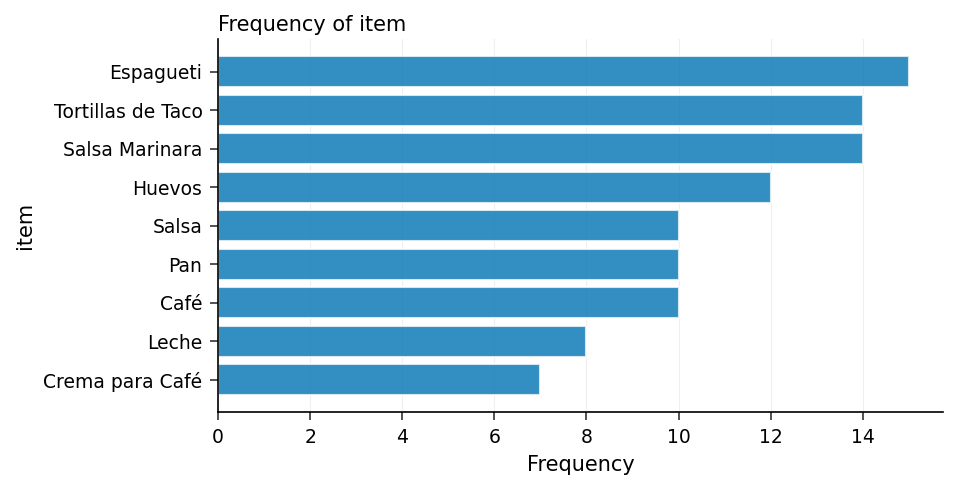

In [2]:
PROCEDIMIENTO IMPRIMIR DATOS=store_transactions(obs=12) ETIQUETA;
    ETIQUETA basket_id = 'ID de Cesta'
          item      = 'Producto';
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=store_transactions ORDER=FRECUENCIAS;
    TABLES item / nocum;
    TÍTULO 'Frecuencia General de Compra de Productos';
EJECUTAR;

## Paso 3 — Minar reglas de asociación con PROC MBANALYSIS

Ahora el análisis central. Apuntamos MBANALYSIS al registro de transacciones y declaramos qué columna identifica la cesta (`TRANSACTION`) y cuál contiene el producto (`ITEM`). Tres umbrales mantienen el conjunto de reglas enfocado en patrones que valen la pena:

- `MINSUPPORT=0.10` — una regla debe aparecer en al menos el 10% de las cestas, filtrando coincidencias raras.
- `MINCONFIDENCE=0.50` — dado el antecedente, el consecuente debe seguir al menos la mitad de las veces.
- `MINLIFT=1.20` — mantener solo reglas al menos 20% más fuertes que el azar, para detectar afinidades genuinas en lugar de artefactos de productos básicos populares.

La instrucción `OUTPUT` captura las reglas generadas y los conjuntos de artículos frecuentes en conjuntos de datos para su clasificación posterior.

In [3]:
PROCEDIMIENTO mbanalysis DATOS=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    SALIDA rules=affinity_rules items=frequent_items;
    TÍTULO 'Reglas de Asociación de la Cesta de Mercado';
EJECUTAR;

                                       Frecuencia General de Compra de Productos                                        


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Café                           Crema para Café                    0.1373     0.7000     5.1000
  Crema para Café                Café                               0.1373     1.0000     5.1000
  Salsa                          Tortillas de Taco                  0.1961     1.0000     3.6429
  Tortillas de


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Paso 4 — Clasificar oportunidades de venta cruzada por lift

El listado de MBANALYSIS muestra cada regla que califica, pero el equipo de merchandising quiere primero las afinidades *más fuertes*. Ordenamos el conjunto de datos capturado `affinity_rules` por lift descendente (luego confianza como desempate) e imprimimos las reglas principales. Una regla como `Tortillas de Taco -> Salsa` con alto lift y alta confianza es un candidato de libro de texto para paquete promocional: colocar los productos juntos, o auto-sugerir salsa cuando un cliente agrega tortillas de taco en línea.

In [4]:
PROCEDIMIENTO ORDENAR DATOS=affinity_rules out=rules_by_lift;
    POR DESCENDENTE lift DESCENDENTE confidence;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=rules_by_lift(obs=15) ETIQUETA;
    VAR antecedent consequent support confidence lift;
    ETIQUETA antecedent  = 'Si la cesta contiene'
          consequent  = 'Entonces también compra'
          support     = 'Soporte'
          confidence  = 'Confianza'
          lift        = 'Lift';
    TÍTULO 'Principales Reglas de Venta Cruzada Ordenadas por Lift';
EJECUTAR;

                                 Principales Reglas de Venta Cruzada Ordenadas por Lift                                 

  Obs  Si la cesta contiene   Entonces también compra   Soporte  Confianza      Lift
    1  Crema para Café       Café                      0.137255  1.0        5.1
    2  Café                  Crema para Café           0.137255  0.7        5.1
    3  Salsa                 Tortillas de Taco         0.196078  1.0        3.642857
    4  Tortillas de Taco     Salsa                     0.196078  0.714286   3.642857
    5  Salsa Marinara        Espagueti                 0.27451   1.0        3.4
    6  Espagueti             Salsa Marinara            0.27451   0.933333   3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Paso 5 — Revisar los conjuntos de artículos frecuentes

Los conjuntos de artículos frecuentes que superaron el umbral de soporte son los bloques de construcción en bruto detrás de las reglas. Ordenarlos por soporte le indica al equipo de categoría qué *combinaciones* de productos (no solo artículos individuales) son lo suficientemente populares como para merecer exhibidores de cabecera de góndola dedicados o precios combinados.

In [5]:
PROCEDIMIENTO ORDENAR DATOS=frequent_items out=itemsets_by_support;
    POR DESCENDENTE support;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=itemsets_by_support(obs=15) ETIQUETA;
    ETIQUETA itemset='Conjunto de Artículos' support='Soporte' length='Longitud';
    TÍTULO 'Conjuntos de Artículos Más Frecuentes';
EJECUTAR;

                                         Conjuntos de Artículos Más Frecuentes                                          

  Obs      Conjunto de Artículos   Soporte  Longitud
    1  Espagueti                  0.294118  1
    2  Tortillas de Taco          0.27451   1
    3  Salsa Marinara             0.27451   1
    4  Espagueti, Salsa Marinara  0.27451   2
    5  Huevos                     0.235294  1
    6  Salsa                      0.196078  1
    7  Café                       0.196078  1
    8  Salsa, Tortillas de Taco   0.196078  2
    9  Leche                      0.156863  1
   10  Pan                        0.156863  1
   11  Crema para Café            0.137255  1
   12  Café, Crema para Café      0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Interpretando los resultados

**Lo que encontró el análisis.** Debido a que cada cesta se construyó alrededor de una única persona compradora, el minero recupera exactamente las tres relaciones sembradas y nada espurio. Seis reglas superan los tres umbrales — las tres afinidades en ambas direcciones:

| Antecedente | Consecuente | Soporte | Confianza | Lift |
|-------------|-------------|---------|-----------|------|
| Espagueti | Salsa Marinara | 0.275 | 0.93 | 3.40 |
| Salsa Marinara | Espagueti | 0.275 | 1.00 | 3.40 |
| Tortillas de Taco | Salsa | 0.196 | 0.71 | 3.64 |
| Salsa | Tortillas de Taco | 0.196 | 1.00 | 3.64 |
| Café | Crema para Café | 0.137 | 0.70 | 5.10 |
| Crema para Café | Café | 0.137 | 1.00 | 5.10 |

Todo lift está muy por encima de 1, confirmando que estos productos co-ocurren mucho más de lo que predeciría el azar. Fundamentalmente, los productos básicos ampliamente comprados no forman **ninguna regla**: huevos (12 compras), pan (10) y leche (8) aparecen todos en la tabulación de PROC FREQ, pero como caen en las cestas independientemente de cualquier persona, su lift hacia otros artículos nunca alcanza el umbral de 1.20, así que nunca se hacen pasar por afinidades genuinas. El listado de conjuntos frecuentes hace el mismo punto estructuralmente: de los 12 conjuntos que superan el umbral de soporte, los únicos conjuntos de múltiples artículos son exactamente los tres pares sembrados.

**Leyendo las métricas juntas.** Las reglas en dirección inversa llevan confianza 1.00 (en estos datos, la salsa marinara, la salsa y la crema esencialmente nunca aparecen sin su artículo ancla), mientras que las reglas directas se ubican en 0.70-0.93 (el ancla a veces aparece sola). Café -> Crema para Café tiene el lift más alto (5.10) pero el soporte más bajo (0.137) — una afinidad fuerte pero de menor volumen — mientras que Espagueti -> Salsa Marinara alcanza más cestas (soporte 0.275). El lift identifica *cuáles* afinidades son reales; la confianza indica *qué tan confiable* es cada una para una recomendación; el soporte indica *con qué frecuencia* se podrá actuar sobre ella.

**Acciones de negocio.**

- **Paquetes promocionales** — combinar los artículos antecedente/consecuente de mayor lift (café + crema para café, lift 5.1) en un combo con descuento.
- **Adyacencias de anaquel** — co-ubicar productos frecuentemente vinculados (espagueti junto a la salsa marinara, soporte 0.275) para que el consecuente sea un complemento fácil en el punto de decisión.
- **Recomendaciones en línea** — alimentar las reglas de mayor confianza en un widget de "los clientes también compraron" para que el consecuente se sugiera en el momento en que el antecedente entra al carrito.
- **Inventario y pronóstico** — cuando un antecedente entra en promoción, aumentar el stock de sus consecuentes de alta confianza anticipando el lift.

**Advertencias.** Las reglas de asociación describen *correlación en co-compra*, no causalidad, y los umbrales son palancas, no verdades: bajar `MINSUPPORT=` expone combinaciones más raras al costo de un conjunto de reglas más ruidoso, mientras que subir `MINLIFT=` y `MINCONFIDENCE=` produce menos reglas pero más confiables. El tamaño de la muestra también importa — esta ejecución sin licencia mina 51 cestas, suficiente para hacer inconfundibles las afinidades sembradas; una ejecución de producción sobre una temporada completa estabilizaría las estimaciones de soporte y expondría patrones más sutiles.